In [1]:
from keras.layers import Input, Dense
from keras.models import Model
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [4]:
(xtrain, ytrain), (xtest, ytest) = mnist.load_data()
print('XTrain class = ', type(xtrain))
print('YTrain class = ', type(ytrain))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step 
XTrain class =  <class 'numpy.ndarray'>
YTrain class =  <class 'numpy.ndarray'>


In [5]:
print('XTrain shape = ', xtrain.shape)
print('XTest shape = ', xtest.shape)
print('YTrain shape = ', ytrain.shape)
print('YTest shape = ', ytest.shape)

XTrain shape =  (60000, 28, 28)
XTest shape =  (10000, 28, 28)
YTrain shape =  (60000,)
YTest shape =  (10000,)


In [6]:
print('YTrain values = ', np.unique(ytrain))
print('YTest values = ', np.unique(ytest))

YTrain values =  [0 1 2 3 4 5 6 7 8 9]
YTest values =  [0 1 2 3 4 5 6 7 8 9]


In [7]:
unique, counts = np.unique(ytrain, return_counts = True)
print('YTrain distribution = ', dict(zip(unique, counts)))
unique, counts = np.unique(ytest, return_counts = True)
print('YTest distribution = ', dict(zip(unique, counts)))

YTrain distribution =  {np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}
YTest distribution =  {np.uint8(0): np.int64(980), np.uint8(1): np.int64(1135), np.uint8(2): np.int64(1032), np.uint8(3): np.int64(1010), np.uint8(4): np.int64(982), np.uint8(5): np.int64(892), np.uint8(6): np.int64(958), np.uint8(7): np.int64(1028), np.uint8(8): np.int64(974), np.uint8(9): np.int64(1009)}


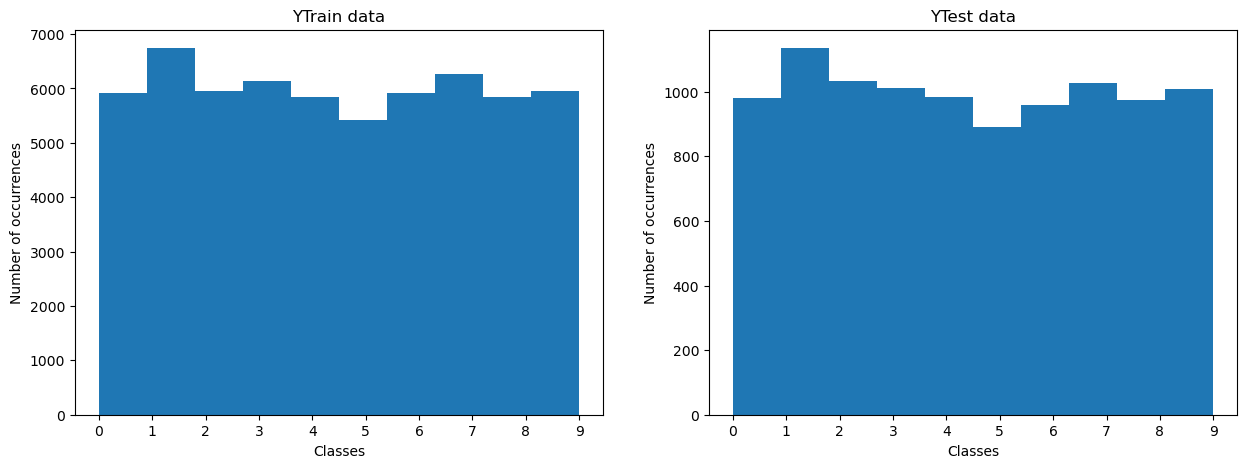

In [8]:
fig, axs = plt.subplots(1, 2, figsize = (15, 5))
axs[0].hist(ytrain, ec = 'black')
axs[0].set_title('YTrain data')
axs[0].set_xlabel('Classes')
axs[0].set_ylabel('Number of occurrences')
axs[1].hist(ytest, ec = 'black')
axs[1].set_title('YTest data')
axs[1].set_xlabel('Classes')
axs[1].set_ylabel('Number of occurrences')
# we want to show all ticks....
axs[0].set_xticks(np.arange(10))
axs[1].set_xticks(np.arange(10))
plt.show()

In [9]:
xtrain = xtrain.astype('float32')/255
xtest = xtest.astype('float32')/255
# data reshapping
xtrain = xtrain.reshape((len(xtrain), np.prod(xtrain.shape[1:])))
xtest = xtest.reshape((len(xtest), np.prod(xtest.shape[1:])))
print(xtrain.shape)
print(xtest.shape)


(60000, 784)
(10000, 784)


In [10]:
InputModel = Input(shape = (784,))
EncodedLayer = Dense(32, activation = 'relu')(InputModel)
DecodedLayer = Dense(784, activation = 'sigmoid')(EncodedLayer)
AutoencoderModel = Model(InputModel, DecodedLayer)
# we can summarize our model
AutoencoderModel.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │          25,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 784)                 │          25,872 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)